In [43]:
import seaborn as sns
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from adjustText import adjust_text

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

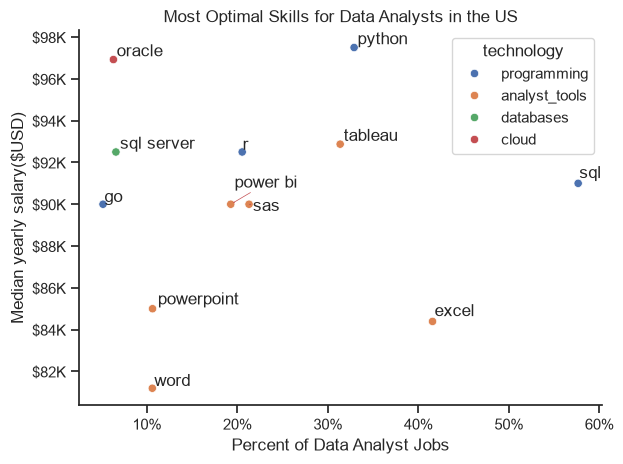

In [ ]:
df_DA = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].copy()
df_DA = df_DA.dropna(subset=['salary_year_avg'])

exploded = df_DA.explode('job_skills')

grouped_m = exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
grouped_m = grouped_m.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

Df_jobcount = len(df_DA)

grouped_m['skill_percentage'] = (grouped_m['skill_count'] / Df_jobcount) * 100

limit_perc = 5
high_demand = grouped_m[grouped_m['skill_percentage'] > limit_perc]

df_technology = df['job_type_skills'].copy()
df_technology = df_technology.drop_duplicates()
df_technology = df_technology.dropna()

technology_dict = {}
for row in df_technology:

    row_dict = ast.literal_eval(row)

    for key, value in row_dict.items():

        if key in technology_dict:
            technology_dict[key] += value

        else:
            technology_dict[key] = value


for key, value in technology_dict.items():
     technology_dict[key] = list(set(value))

df_technology = pd.DataFrame(list(technology_dict.items()),columns=['technology', 'skills'])
df_technology = df_technology.explode('skills')

plot_df = high_demand.reset_index().merge(
    df_technology,
    left_on='job_skills',
    right_on='skills').drop_duplicates(subset='job_skills')

fig, ax = plt.subplots()

# plot_df.plot(kind='scatter',x='skill_percentage',y='median_salary',ax=ax)
sns.scatterplot(data = plot_df, x='skill_percentage', y='median_salary',hue = 'technology', ax=ax)
sns.despine()
sns.set_theme(style = 'ticks')
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median yearly salary($USD)')
plt.title('Most Optimal Skills for Data Analysts in the US')

texts = []
from matplotlib.ticker import PercentFormatter
for txt in plot_df['job_skills']:

    row = plot_df[plot_df['job_skills'] == txt].iloc[0]
    text = plt.text(row['skill_percentage'],row['median_salary'],txt)
    texts.append(text)

adjust_text(texts,arrowprops=dict(arrowstyle='->', color='r', lw=0.5))

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals = 0))

plt.tight_layout()